# HW7

In [1]:
!pip install -q torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2
!pip install -q facenet-pytorch torchmetrics
!pip install -q torch-fidelity
import os
import torch
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from getpass import getpass
from facenet_pytorch import MTCNN
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
import torchvision.utils as vutils
import pandas as pd
import numpy as np
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [2]:
os.environ["KAGGLE_USERNAME"] = getpass("kg username: ").strip()
os.environ["KAGGLE_KEY"] = getpass("kg api k: ").strip()

!pip install -q kaggle facenet-pytorch torchmetrics

!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip -d celeba

kg username: ··········
kg api k: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:05<00:00, 245MB/s]



**Подготовить датасет: использовать детектор/сегментатор для предварительного вырезания лиц людей. Можно также добавить технику выравнивания лица (не обязательно)**

In [3]:
cropped_dir = Path('celeba_cropped')
cropped_dir.mkdir(exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=False, device=device, image_size=64, margin=10)

orig_images_dir = Path('celeba/img_align_celeba/img_align_celeba')

image_paths = list(orig_images_dir.glob('*.jpg'))[:30000]

for path in tqdm(image_paths):
    img = cv2.imread(str(path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        save_path = cropped_dir / path.name
        if not save_path.exists():
            mtcnn(img, save_path=str(save_path))

print(f"Вырезано лиц: {len(list(cropped_dir.glob('*.jpg')))}")

  0%|          | 0/30000 [00:00<?, ?it/s]

Вырезано лиц: 29955


**Обучить !самописный! GAN для задачи безусловной генерации лиц**

In [4]:
class FaceDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_paths = list(Path(img_dir).glob('*.jpg'))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx])
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = FaceDataset('celeba_cropped', transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)

class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1).squeeze(1)

  0%|          | 0/234 [00:00<?, ?it/s]

Epoch [1/20] Loss D: 0.3634, loss G: 4.1816


  0%|          | 0/234 [00:00<?, ?it/s]

Epoch [2/20] Loss D: 0.4766, loss G: 4.5460


  0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch [18/20] Loss D: 0.2800, loss G: 5.0786


  0%|          | 0/234 [00:00<?, ?it/s]

Epoch [19/20] Loss D: 0.1490, loss G: 3.9501


  0%|          | 0/234 [00:00<?, ?it/s]

Epoch [20/20] Loss D: 0.2684, loss G: 3.4458


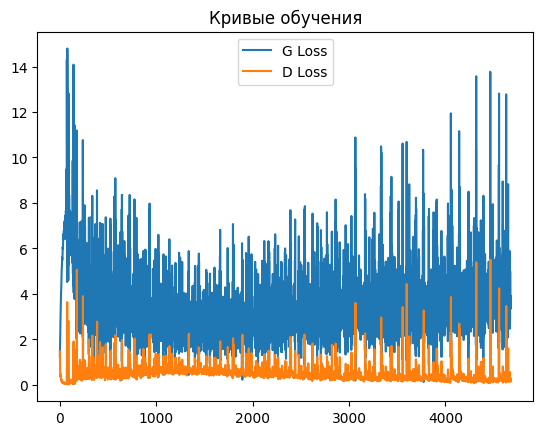

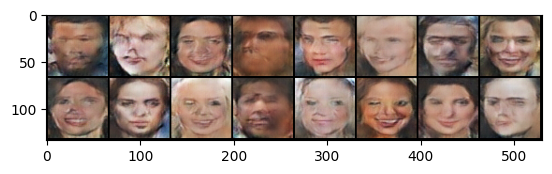

In [5]:
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

G_losses = []
D_losses = []
epochs = 20

for epoch in range(epochs):
    for i, real_imgs in enumerate(tqdm(dataloader, leave=False)):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        D.zero_grad()
        out_real = D(real_imgs)
        loss_D_real = criterion(out_real, real_labels)

        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        out_fake = D(fake_imgs.detach())
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        G.zero_grad()
        out_fake = D(fake_imgs)
        loss_G = criterion(out_fake, real_labels)
        loss_G.backward()
        opt_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D.item():.4f}, loss G: {loss_G.item():.4f}")

plt.plot(G_losses, label='G Loss')
plt.plot(D_losses, label='D Loss')
plt.legend()
plt.title("Кривые обучения")
plt.show()

test_noise = torch.randn(16, z_dim, 1, 1, device=device)
with torch.no_grad():
    fake_grid = G(test_noise).cpu()
grid = vutils.make_grid(fake_grid, padding=2, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()

**А затем эту же сетку преобразовать в условную и обучить для задачи условной генерации лиц по полу человека (или любому другому признаку)**

In [6]:
df_attr = pd.read_csv('celeba/list_attr_celeba.csv')
df_attr = df_attr[['image_id', 'Male']]
df_attr['Male'] = df_attr['Male'].replace(-1, 0)
attr_dict = dict(zip(df_attr.image_id, df_attr.Male))

class CondFaceDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_paths = list(Path(img_dir).glob('*.jpg'))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        path = self.img_paths[idx]
        img = Image.open(path)
        if self.transform:
            img = self.transform(img)
        label = attr_dict.get(path.name, 0)
        return img, torch.tensor(label, dtype=torch.float32)

cond_dataset = CondFaceDataset('celeba_cropped', transform=transform)
cond_dataloader = DataLoader(cond_dataset, batch_size=128, shuffle=True, drop_last=True, num_workers=2)


class CondGenerator(nn.Module):
    def __init__(self, z_dim=100, embed_size=50):
        super().__init__()
        self.label_emb = nn.Embedding(2, embed_size)
        self.net = Generator(z_dim + embed_size).net

    def forward(self, noise, labels):
        emb = self.label_emb(labels.long()).view(-1, 50, 1, 1)
        x = torch.cat([noise, emb], dim=1)
        return self.net(x)

class CondDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = Discriminator().net
        self.label_emb = nn.Embedding(2, 1)
        self.net[0] = nn.Conv2d(4, 32, 4, 2, 1, bias=False)

    def forward(self, img, labels):
        b_size = img.size(0)
        emb = self.label_emb(labels.long()).view(b_size, 1, 1, 1).expand(b_size, 1, 64, 64)
        x = torch.cat([img, emb], dim=1)
        return self.net(x).view(-1, 1).squeeze(1)

cG = CondGenerator(z_dim).to(device)
cD = CondDiscriminator().to(device)

opt_cG = optim.Adam(cG.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_cD = optim.Adam(cD.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs_cgan = 20

for epoch in range(epochs_cgan):
    for i, (real_imgs, labels) in enumerate(tqdm(cond_dataloader, leave=False)):
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        b_size = real_imgs.size(0)

        real_target = torch.ones(b_size, device=device)
        fake_target = torch.zeros(b_size, device=device)

        cD.zero_grad()
        out_real = cD(real_imgs, labels)
        loss_D_real = criterion(out_real, real_target)

        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake_imgs = cG(noise, labels)
        out_fake = cD(fake_imgs.detach(), labels)
        loss_D_fake = criterion(out_fake, fake_target)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_cD.step()

        cG.zero_grad()
        out_fake = cD(fake_imgs, labels)
        loss_G = criterion(out_fake, real_target)
        loss_G.backward()
        opt_cG.step()

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

...

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/234 [00:00<?, ?it/s]

**Метрики: посчитать FID и IS, показать кривые обучения**

In [7]:
fid = FrechetInceptionDistance(feature=2048).to(device)
inception = InceptionScore().to(device)

def to_uint8(imgs):
    return ((imgs + 1) / 2 * 255).to(torch.uint8)

for i, (real_imgs, _) in enumerate(tqdm(cond_dataloader, total=50)):
    if i >= 50: break

    real_imgs = real_imgs.to(device)
    noise = torch.randn(real_imgs.size(0), z_dim, 1, 1, device=device)
    labels = torch.randint(0, 2, (real_imgs.size(0),), dtype=torch.float32).to(device)

    with torch.no_grad():
        fake_imgs = cG(noise, labels)

    fid.update(to_uint8(real_imgs), real=True)
    fid.update(to_uint8(fake_imgs), real=False)
    inception.update(to_uint8(fake_imgs))

fid_score = fid.compute()
is_score, _ = inception.compute()
print(f"FID Score: {fid_score.item():.4f}")
print(f"Inception Score (IS): {is_score.item():.4f}")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 269MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  0%|          | 0/50 [00:00<?, ?it/s]

FID Score: 253.4156
Inception Score (IS): 2.0554


**Показать, что из одного вектора шума с разными метками получаются разные изображения**

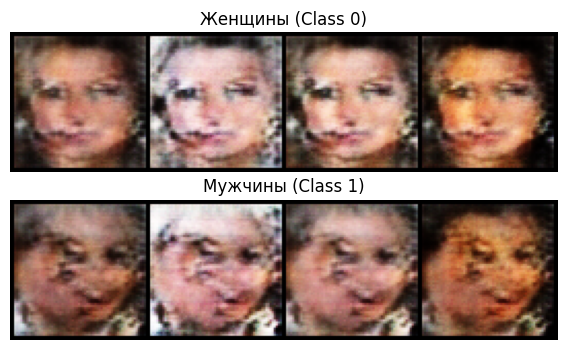

In [12]:
fixed_noise = torch.randn(4, z_dim, 1, 1, device=device)
labels_female = torch.zeros(4, device=device)
labels_male = torch.ones(4, device=device)

with torch.no_grad():
    fake_females = cG(fixed_noise, labels_female).cpu()
    fake_males = cG(fixed_noise, labels_male).cpu()

grid_f = vutils.make_grid(fake_females, padding=2, normalize=True)
grid_m = vutils.make_grid(fake_males, padding=2, normalize=True)

fig, axs = plt.subplots(2, 1, figsize=(8, 4))
axs[0].imshow(np.transpose(grid_f, (1, 2, 0)))
axs[0].set_title("Женщины (Class 0)")
axs[0].axis('off')

axs[1].imshow(np.transpose(grid_m, (1, 2, 0)))
axs[1].set_title("Мужчины (Class 1)")
axs[1].axis('off')
plt.show()

**Обучите Wasserstein GAN для решения задачи генерации лиц (+5 баллов)**

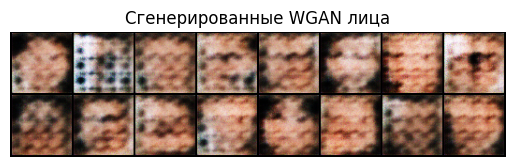

In [9]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )
    def forward(self, x):
        return self.net(x).view(-1, 1).squeeze(1)

wG = Generator(z_dim).to(device)
wC = Critic().to(device)
opt_wG = optim.RMSprop(wG.parameters(), lr=0.00005)
opt_wC = optim.RMSprop(wC.parameters(), lr=0.00005)
clip_value = 0.01
n_critic = 5

for epoch in range(20):
    for i, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        wC.zero_grad()
        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake_imgs = wG(noise)
        loss_C = -(torch.mean(wC(real_imgs)) - torch.mean(wC(fake_imgs.detach())))
        loss_C.backward()
        opt_wC.step()
        for p in wC.parameters():
            p.data.clamp_(-clip_value, clip_value)

        if i % n_critic == 0:
            wG.zero_grad()
            fake_imgs = wG(noise)
            loss_G = -torch.mean(wC(fake_imgs))
            loss_G.backward()
            opt_wG.step()

test_noise = torch.randn(16, z_dim, 1, 1, device=device)
with torch.no_grad():
    fake_imgs = wG(test_noise).cpu()
import torchvision.utils as vutils
import matplotlib.pyplot as plt
img_grid = vutils.make_grid(fake_imgs, padding=2, normalize=True)
plt.imshow(np.transpose(img_grid, (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные WGAN лица")
plt.show()